In [3]:
!pip install nibabel
!pip install simpleITK
!pip install ipywidgets jupyterlab_widgets
!pip install ipywidgets
!pip install scikit-image scipy matplotlib
!pip install numpy

In [2]:
import os
import numpy as np

folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])

print("Number of frames:", len(files))
print(files[:5])

Number of frames: 256
['case_0001_0000.nii.gz', 'case_0002_0000.nii.gz', 'case_0003_0000.nii.gz', 'case_0004_0000.nii.gz', 'case_0005_0000.nii.gz']


Shape: (240, 240, 1)


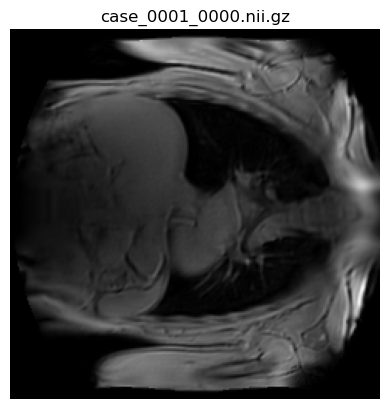

In [3]:
import nibabel as nib
import matplotlib.pyplot as plt

first_file = os.path.join(folder, files[0])
nii = nib.load(first_file)
img = nii.get_fdata()

print("Shape:", img.shape)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(files[0])
plt.show()

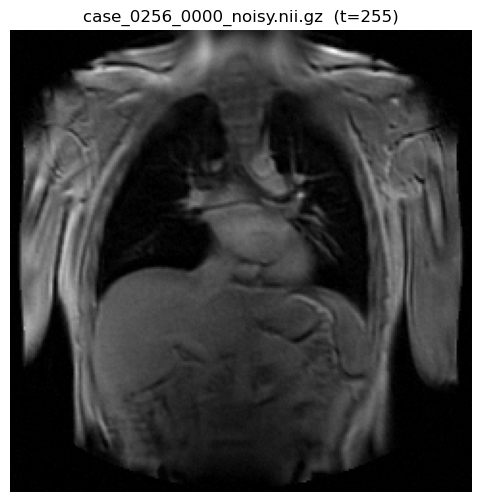

In [8]:
import os, time
import nibabel as nib
import matplotlib.pyplot as plt
from IPython.display import clear_output

folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw_noisy"
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])

for t in range(0, len(files), 5):  # step=5 to go faster; change to 1 for every frame
    clear_output(wait=True)
    img = nib.load(os.path.join(folder, files[t])).get_fdata()

    img = np.rot90(img,1)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"{files[t]}  (t={t})")
    plt.show()

    time.sleep(0.1)  # adjust speed

In [7]:
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, closing, opening, disk
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes
import matplotlib.pyplot as plt

def auto_lung_mask_2d(img, min_size=1500, close_radius=5, open_radius=2, keep_k=2):
    """
    Returns: mask (bool), and (optionally) separated components.
    img: 2D numpy array (float)
    """
    # normalize to [0,1]
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # lungs tend to be darker in many MR sequences => threshold low intensities
    th = threshold_otsu(img)
    mask = img < th

    # remove border-connected background
    mask = clear_border(mask)

    # morphology cleanup
    if open_radius > 0:
        mask = opening(mask, disk(open_radius))
    if close_radius > 0:
        mask = closing(mask, disk(close_radius))

    mask = binary_fill_holes(mask)
    mask = remove_small_objects(mask, min_size=min_size)

    # keep largest connected components (usually 2 lungs)
    lab = label(mask)
    props = sorted(regionprops(lab), key=lambda r: r.area, reverse=True)

    keep = np.zeros_like(mask, dtype=bool)
    for r in props[:keep_k]:
        keep[lab == r.label] = True

    keep = binary_fill_holes(keep)
    return keep

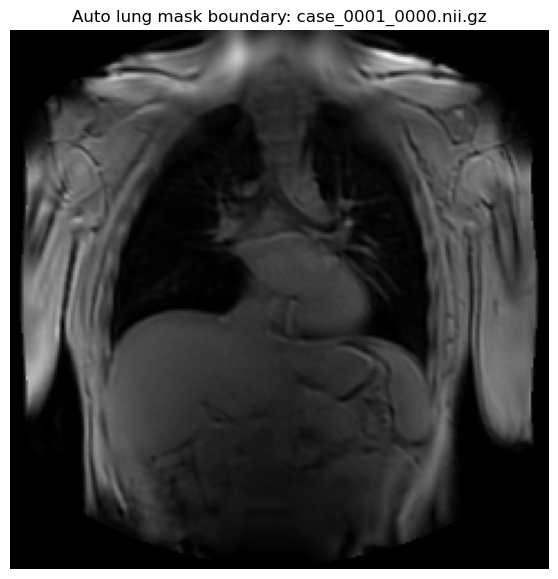

In [11]:
import os
import nibabel as nib

folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])

t0 = 0
# load the 3D volume
img_vol = nib.load(os.path.join(folder, files[t0])).get_fdata()

# select the middle slice (or whichever slice you want)
z = img_vol.shape[2] // 2
img0 = img_vol[:, :, z]

# rotate the 2D slice for display
img0 = np.rot90(img0, 1)

# generate the lung mask for that 2D slice
mask0 = auto_lung_mask_2d(img0)

plt.figure(figsize=(7,7))
plt.imshow(img0, cmap="gray")
plt.contour(mask0, colors="y", linewidths=1)
plt.axis("off")
plt.title(f"Auto lung mask boundary: {files[t0]}")
plt.show()

In [12]:
masks = []
for f in files[:50]:  # change 50 -> len(files) when happy
    img_vol = nib.load(os.path.join(folder, f)).get_fdata()
    
    # select the middle slice
    z = img_vol.shape[2] // 2
    img = img_vol[:, :, z]
    
    # rotate for display
    img = np.rot90(img, 1)
    
    # now this works
    m = auto_lung_mask_2d(img)
    masks.append(m)

masks = np.stack(masks, axis=0)  # (T,H,W)
print("masks shape:", masks.shape)

masks shape: (50, 240, 240)


Processing frame 1/256: case_0001_0000.nii.gz
Processing frame 2/256: case_0002_0000.nii.gz
Processing frame 3/256: case_0003_0000.nii.gz
Processing frame 4/256: case_0004_0000.nii.gz
Processing frame 5/256: case_0005_0000.nii.gz
Processing frame 6/256: case_0006_0000.nii.gz
Processing frame 7/256: case_0007_0000.nii.gz
Processing frame 8/256: case_0008_0000.nii.gz
Processing frame 9/256: case_0009_0000.nii.gz
Processing frame 10/256: case_0010_0000.nii.gz
Processing frame 11/256: case_0011_0000.nii.gz
Processing frame 12/256: case_0012_0000.nii.gz
Processing frame 13/256: case_0013_0000.nii.gz
Processing frame 14/256: case_0014_0000.nii.gz
Processing frame 15/256: case_0015_0000.nii.gz
Processing frame 16/256: case_0016_0000.nii.gz
Processing frame 17/256: case_0017_0000.nii.gz
Processing frame 18/256: case_0018_0000.nii.gz
Processing frame 19/256: case_0019_0000.nii.gz
Processing frame 20/256: case_0020_0000.nii.gz
Processing frame 21/256: case_0021_0000.nii.gz
Processing frame 22/25

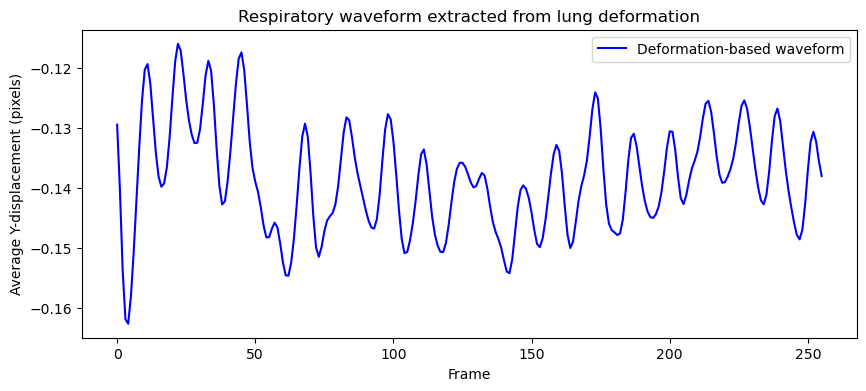

In [13]:
import nibabel as nib
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Parameters
folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"
num_frames = 256  # change as needed

waveform = []

# Load first frame (reference)
ref_file = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])[0]
img_ref_vol = nib.load(os.path.join(folder, ref_file)).get_fdata()
z_ref = img_ref_vol.shape[2] // 2
img_ref = np.rot90(img_ref_vol[:, :, z_ref]).astype(np.float32)
img_ref_sitk = sitk.GetImageFromArray(img_ref)

# Loop through frames
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])[:num_frames]

for t, f in enumerate(files):
    print(f"Processing frame {t+1}/{len(files)}: {f}")
    
    # Load middle slice of current frame
    img_vol = nib.load(os.path.join(folder, f)).get_fdata()
    z = img_vol.shape[2] // 2
    img_slice = np.rot90(img_vol[:, :, z]).astype(np.float32)
    
    img_slice_sitk = sitk.GetImageFromArray(img_slice)
    
    # Demons registration (intensity-based)
    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.0)
    
    displacement_field = demons.Execute(img_ref_sitk, img_slice_sitk)
    
    # Convert displacement field to numpy array
    disp_arr = sitk.GetArrayFromImage(displacement_field)  # shape: (H, W, 2)
    
    # Average displacement along y-axis (superior-inferior)
    avg_disp_y = np.mean(disp_arr[..., 0])
    waveform.append(avg_disp_y)

# Convert to numpy array and smooth
waveform = np.array(waveform)
waveform_smooth = gaussian_filter1d(waveform, sigma=2)

# Plot the waveform
plt.figure(figsize=(10,4))
plt.plot(waveform_smooth, color='b', label='Deformation-based waveform')
plt.xlabel("Frame")
plt.ylabel("Average Y-displacement (pixels)")
plt.title("Respiratory waveform extracted from lung deformation")
plt.legend()
plt.show()

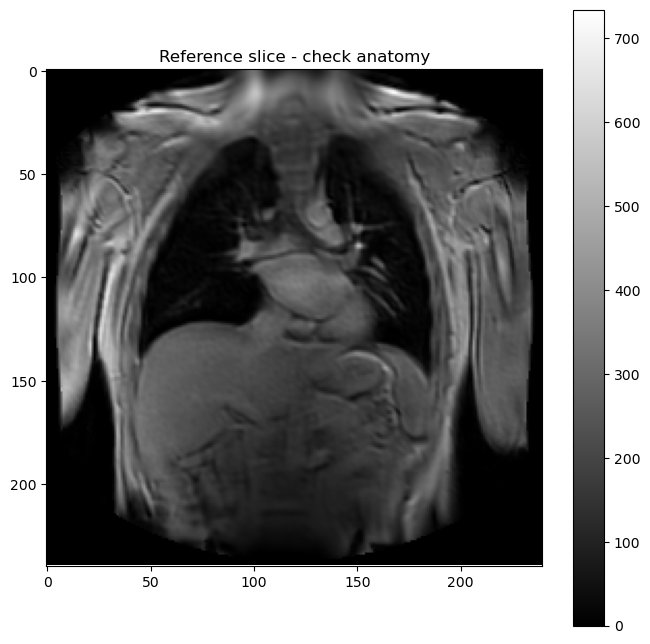

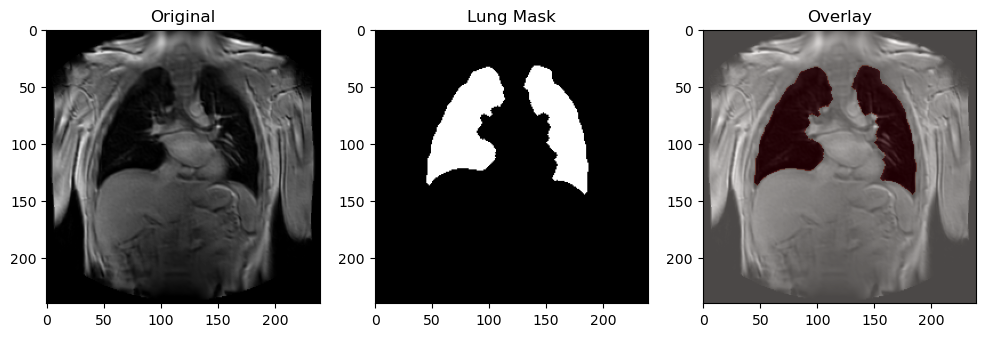

Processing frame 1/256: case_0001_0000.nii.gz
Processing frame 2/256: case_0002_0000.nii.gz
Processing frame 3/256: case_0003_0000.nii.gz
Processing frame 4/256: case_0004_0000.nii.gz
Processing frame 5/256: case_0005_0000.nii.gz
Processing frame 6/256: case_0006_0000.nii.gz
Processing frame 7/256: case_0007_0000.nii.gz
Processing frame 8/256: case_0008_0000.nii.gz
Processing frame 9/256: case_0009_0000.nii.gz
Processing frame 10/256: case_0010_0000.nii.gz
Processing frame 11/256: case_0011_0000.nii.gz
Processing frame 12/256: case_0012_0000.nii.gz
Processing frame 13/256: case_0013_0000.nii.gz
Processing frame 14/256: case_0014_0000.nii.gz
Processing frame 15/256: case_0015_0000.nii.gz
Processing frame 16/256: case_0016_0000.nii.gz
Processing frame 17/256: case_0017_0000.nii.gz
Processing frame 18/256: case_0018_0000.nii.gz
Processing frame 19/256: case_0019_0000.nii.gz
Processing frame 20/256: case_0020_0000.nii.gz
Processing frame 21/256: case_0021_0000.nii.gz
Processing frame 22/25

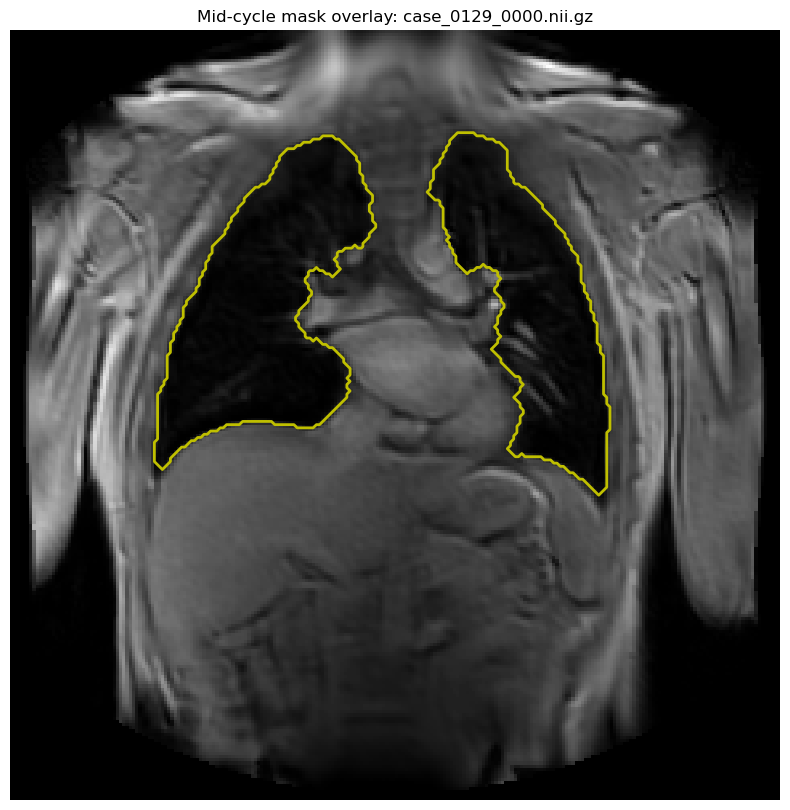

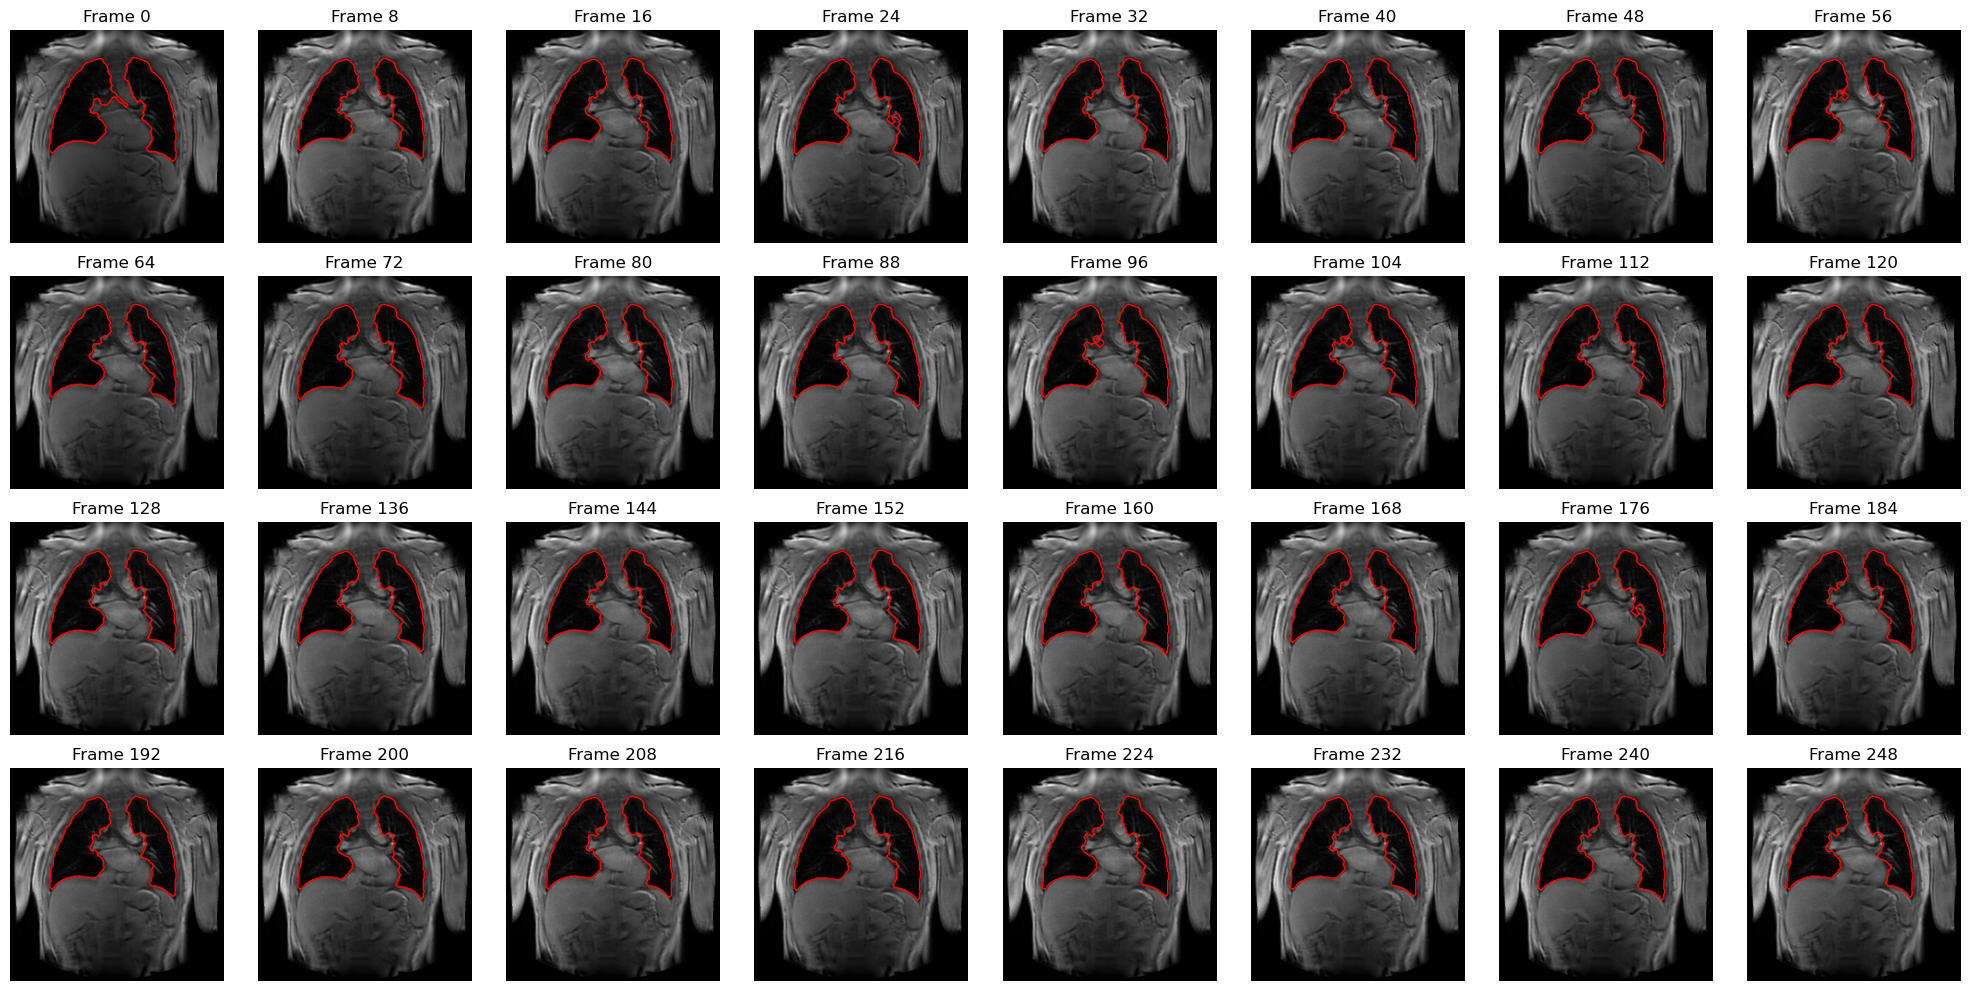

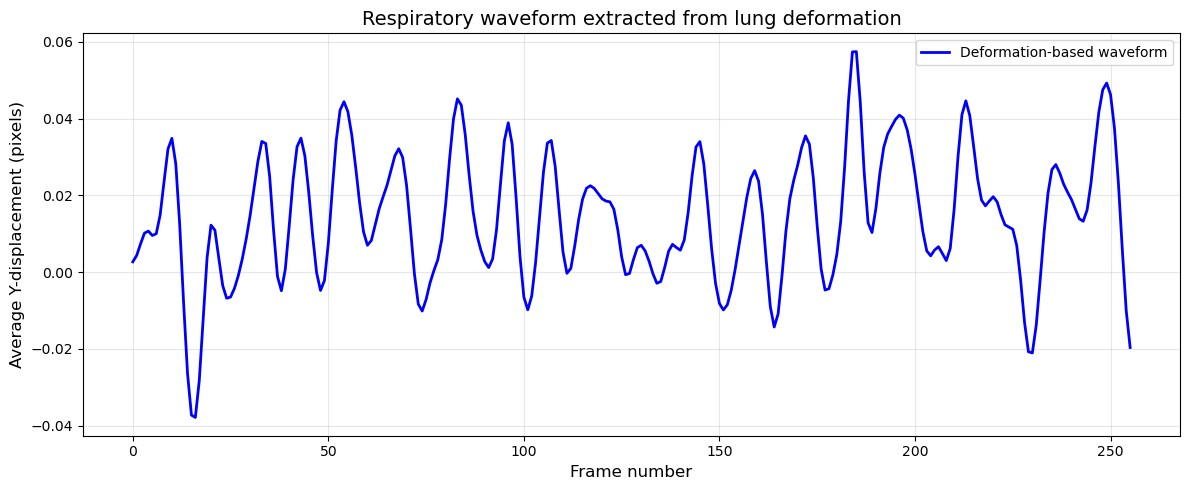

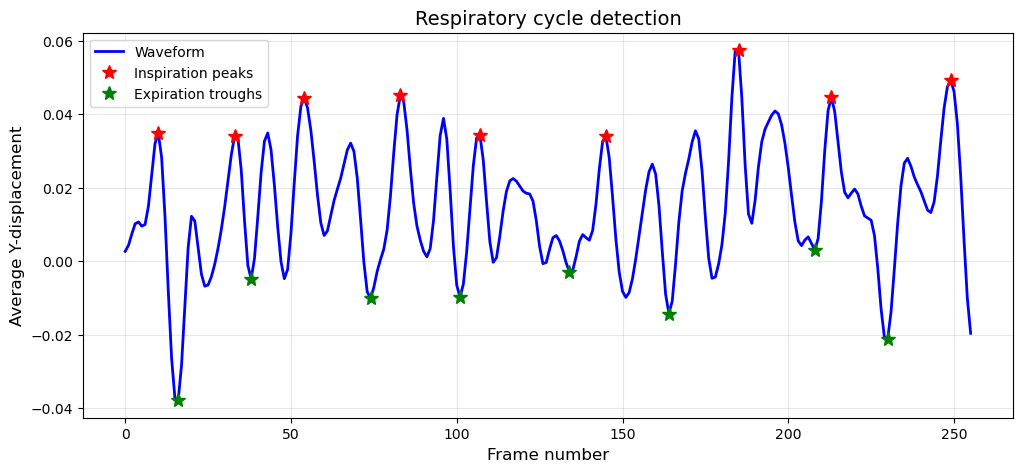

In [14]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from skimage.filters import threshold_otsu, threshold_triangle
from skimage.morphology import remove_small_objects, closing, opening, disk, erosion, dilation
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes, binary_closing, binary_opening
import SimpleITK as sitk

# -----------------------------
# 1️⃣ Improved lung mask function
# -----------------------------
def improved_lung_mask_2d(img, body_threshold=0.1, lung_threshold_factor=0.5):
    """
    Improved lung segmentation that first identifies the body,
    then finds lungs inside the body region.
    """
    img = img.astype(np.float32)
    
    # Normalize for processing
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    # Step 1: Get body mask (everything above background)
    body_mask = img_norm > body_threshold
    body_mask = binary_fill_holes(body_mask)
    body_mask = remove_small_objects(body_mask, min_size=5000)
    
    # Step 2: Within body, find lung tissue (air pockets)
    # Lungs appear dark in MRI/CT, so we want low intensity regions within body
    lung_threshold = threshold_otsu(img_norm[body_mask]) * lung_threshold_factor
    
    # Initial lung candidates (dark regions within body)
    lung_candidates = (img_norm < lung_threshold) & body_mask
    
    # Clean up
    lung_candidates = clear_border(lung_candidates)
    lung_candidates = binary_opening(lung_candidates, structure=disk(2))
    lung_candidates = binary_closing(lung_candidates, structure=disk(3))
    lung_candidates = binary_fill_holes(lung_candidates)
    
    # Step 3: Remove small objects and keep the two largest (left and right lung)
    lung_candidates = remove_small_objects(lung_candidates, min_size=500)
    
    # Label and keep the two largest regions
    labeled = label(lung_candidates)
    props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)
    
    # Keep up to 2 largest regions (left and right lung)
    final_mask = np.zeros_like(lung_candidates, dtype=bool)
    for prop in props[:2]:
        # Check if region is plausible lung (not too large, not at edge)
        if prop.area > 100 and prop.area < 50000:
            # Check region shape - lungs are typically elongated
            if prop.major_axis_length > 0:
                elongation = prop.minor_axis_length / prop.major_axis_length
                if elongation > 0.2 and elongation < 0.9:  # Typical lung shape
                    final_mask[labeled == prop.label] = True
    
    # If we lost one lung, try to recover with different threshold
    if np.sum(final_mask) < 200:
        # Fallback: use triangle threshold which is better for unimodal distributions
        lung_threshold = threshold_triangle(img_norm[body_mask])
        lung_candidates = (img_norm < lung_threshold) & body_mask
        lung_candidates = binary_opening(lung_candidates, structure=disk(2))
        lung_candidates = binary_closing(lung_candidates, structure=disk(3))
        lung_candidates = remove_small_objects(lung_candidates, min_size=500)
        
        labeled = label(lung_candidates)
        props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)
        
        for prop in props[:2]:
            if prop.area > 200:
                final_mask[labeled == prop.label] = True
    
    return final_mask

# -----------------------------
# 2️⃣ Load files and select slices
# -----------------------------
folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])
num_frames = 256  # or len(files)

# Choose mid-cycle frame as reference
mid_idx = num_frames // 2
img_ref_vol = nib.load(os.path.join(folder, files[mid_idx])).get_fdata()
z_ref = img_ref_vol.shape[2] // 2
img_ref = np.rot90(img_ref_vol[:, :, z_ref]).astype(np.float32)

# Display the reference image to check orientation
plt.figure(figsize=(8,8))
plt.imshow(img_ref, cmap='gray')
plt.title("Reference slice - check anatomy")
plt.colorbar()
plt.show()

# Create reference mask
ref_mask = improved_lung_mask_2d(img_ref)

# Visualize the reference mask to verify it's correct
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_ref, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(ref_mask, cmap='gray')
plt.title("Lung Mask")

plt.subplot(1,3,3)
plt.imshow(img_ref, cmap='gray')
plt.imshow(ref_mask, alpha=0.3, cmap='Reds')
plt.title("Overlay")
plt.show()

# Store masks and deformation-based displacements
masks = []
waveform = []

# -----------------------------
# 3️⃣ Loop over frames
# -----------------------------
for t, f in enumerate(files[:num_frames]):
    print(f"Processing frame {t+1}/{num_frames}: {f}")
    
    img_vol = nib.load(os.path.join(folder, f)).get_fdata()
    z = img_vol.shape[2] // 2
    img_slice = np.rot90(img_vol[:, :, z]).astype(np.float32)
    
    # Mask for visualization
    mask_slice = improved_lung_mask_2d(img_slice)
    masks.append(mask_slice)
    
    # Convert to SimpleITK for registration
    img_ref_sitk = sitk.GetImageFromArray(img_ref)
    img_slice_sitk = sitk.GetImageFromArray(img_slice)
    
    # Use the mask to focus registration on lung region
    mask_ref_sitk = sitk.GetImageFromArray(ref_mask.astype(np.uint8))
    
    # Registration with mask
    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.0)
    
    # Use mask to constrain registration to lung region
    displacement_field = demons.Execute(img_ref_sitk, img_slice_sitk)
    disp_arr = sitk.GetArrayFromImage(displacement_field)
    
    # Only compute displacement within the lung mask
    if np.any(ref_mask):
        # Average displacement within lung region
        lung_displacements = disp_arr[ref_mask]
        if len(lung_displacements) > 0:
            avg_disp_y = np.mean(lung_displacements[...,0])
        else:
            avg_disp_y = np.mean(disp_arr[...,0])
    else:
        avg_disp_y = np.mean(disp_arr[...,0])
    
    waveform.append(avg_disp_y)

# -----------------------------
# 4️⃣ Convert masks and waveform to arrays
# -----------------------------
masks = np.stack(masks, axis=0)  # shape: (T,H,W)
waveform = np.array(waveform)
waveform_smooth = gaussian_filter1d(waveform, sigma=2)

# -----------------------------
# 5️⃣ Plot masks and waveform
# -----------------------------
# Show overlay for mid-cycle frame
plt.figure(figsize=(10,10))
plt.imshow(img_ref, cmap='gray')
plt.contour(ref_mask, colors='y', linewidths=2)
plt.title(f"Mid-cycle mask overlay: {files[mid_idx]}")
plt.axis('off')
plt.show()

# Show all frames with masks (every 32nd frame)
# Calculate how many frames we actually have
n_frames_to_show = min(num_frames, 256)  # Don't exceed available frames
n_subplots = 32  # 4 rows x 8 columns
step = max(1, n_frames_to_show // n_subplots)  # Dynamic step size

# Create figure with appropriate number of subplots
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.ravel()

# Ensure z is defined (use middle slice of reference volume if not defined)
try:
    z
except NameError:
    # If z is not defined, use the middle slice of the first frame
    first_vol = nib.load(os.path.join(folder, files[0])).get_fdata()
    z = first_vol.shape[2] // 2
    print(f"z was not defined, set to: {z}")

# Loop through frames at regular intervals
for i in range(n_subplots):
    # Calculate frame index
    frame_idx = min(i * step, n_frames_to_show - 1)
    
    try:
        # Load the image
        img_vol = nib.load(os.path.join(folder, files[frame_idx])).get_fdata()
        
        # Ensure z is within bounds for this volume
        z_use = min(z, img_vol.shape[2] - 1)
        if z_use != z:
            print(f"Warning: Adjusted z from {z} to {z_use} for frame {frame_idx}")
        
        # Get the slice and rotate if needed
        img_slice = np.rot90(img_vol[:, :, z_use]).astype(np.float32)
        
        # Get the corresponding mask (if available)
        if frame_idx < len(masks):
            mask_slice = masks[frame_idx]
        else:
            # Generate mask on the fly if not available
            print(f"Mask not found for frame {frame_idx}, generating...")
            mask_slice = improved_lung_mask_2d(img_slice)
        
        # Display the image
        axes[i].imshow(img_slice, cmap='gray')
        
        # Overlay mask contour if mask exists and has content
        if mask_slice is not None and np.any(mask_slice):
            axes[i].contour(mask_slice, colors='r', linewidths=1)
        else:
            # If no mask, add a small indicator
            axes[i].text(10, 10, "No mask", color='yellow', fontsize=8)
        
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')
        
    except Exception as e:
        # Handle any errors gracefully
        print(f"Error displaying frame {frame_idx}: {e}")
        axes[i].text(0.5, 0.5, f"Error\n{frame_idx}", 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].axis('off')

# Hide any unused subplots (if n_frames_to_show < n_subplots)
for i in range(n_frames_to_show // step + 1, n_subplots):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot respiratory waveform
plt.figure(figsize=(12,5))
plt.plot(waveform_smooth, color='b', linewidth=2, label='Deformation-based waveform')
plt.xlabel("Frame number", fontsize=12)
plt.ylabel("Average Y-displacement (pixels)", fontsize=12)
plt.title("Respiratory waveform extracted from lung deformation", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Also plot the waveform with peaks identified
from scipy.signal import find_peaks

peaks, _ = find_peaks(waveform_smooth, distance=20)
troughs, _ = find_peaks(-waveform_smooth, distance=20)

plt.figure(figsize=(12,5))
plt.plot(waveform_smooth, color='b', linewidth=2, label='Waveform')
plt.plot(peaks, waveform_smooth[peaks], 'r*', markersize=10, label='Inspiration peaks')
plt.plot(troughs, waveform_smooth[troughs], 'g*', markersize=10, label='Expiration troughs')
plt.xlabel("Frame number", fontsize=12)
plt.ylabel("Average Y-displacement", fontsize=12)
plt.title("Respiratory cycle detection", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Processing 1/256
Processing 2/256
Processing 3/256
Processing 4/256
Processing 5/256
Processing 6/256
Processing 7/256
Processing 8/256
Processing 9/256
Processing 10/256
Processing 11/256
Processing 12/256
Processing 13/256
Processing 14/256
Processing 15/256
Processing 16/256
Processing 17/256
Processing 18/256
Processing 19/256
Processing 20/256
Processing 21/256
Processing 22/256
Processing 23/256
Processing 24/256
Processing 25/256
Processing 26/256
Processing 27/256
Processing 28/256
Processing 29/256
Processing 30/256
Processing 31/256
Processing 32/256
Processing 33/256
Processing 34/256
Processing 35/256
Processing 36/256
Processing 37/256
Processing 38/256
Processing 39/256
Processing 40/256
Processing 41/256
Processing 42/256
Processing 43/256
Processing 44/256
Processing 45/256
Processing 46/256
Processing 47/256
Processing 48/256
Processing 49/256
Processing 50/256
Processing 51/256
Processing 52/256
Processing 53/256
Processing 54/256
Processing 55/256
Processing 56/256
P

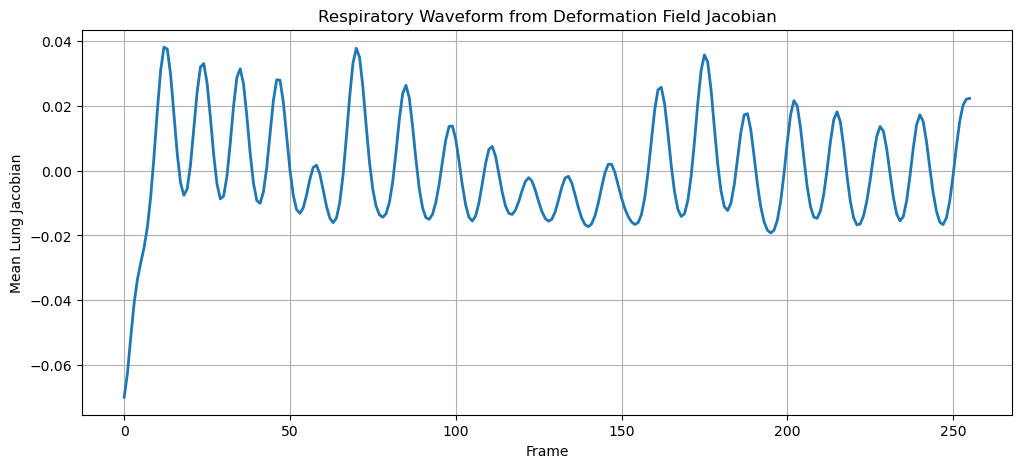

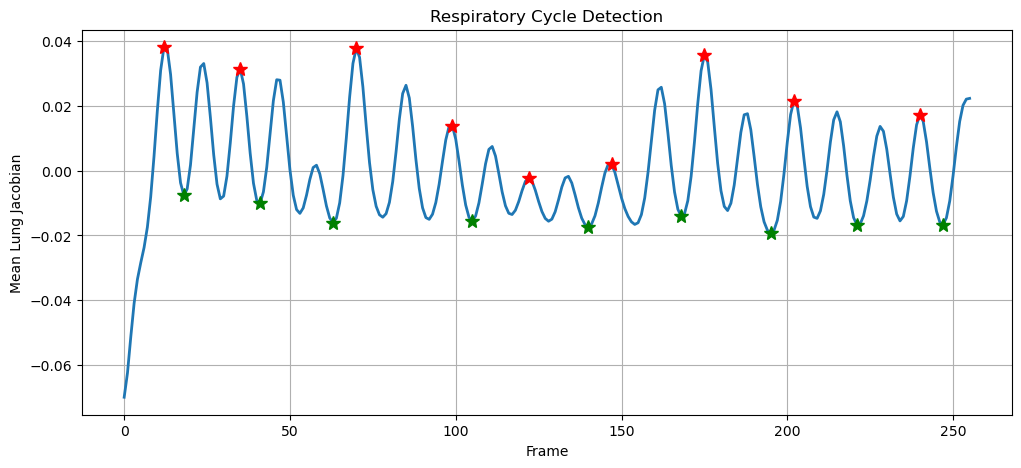

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk

from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes, gaussian_filter1d
from skimage.filters import threshold_otsu, threshold_triangle
from scipy.signal import find_peaks

# -----------------------------
# 1️⃣ Improved Lung Mask
# -----------------------------
def improved_lung_mask_2d(img, body_threshold=0.1, lung_threshold_factor=0.5):

    img = img.astype(np.float32)
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Body mask
    body_mask = img_norm > body_threshold
    body_mask = binary_fill_holes(body_mask)
    body_mask = remove_small_objects(body_mask, min_size=5000)

    # Lung candidates (dark regions inside body)
    lung_threshold = threshold_otsu(img_norm[body_mask]) * lung_threshold_factor
    lung_candidates = (img_norm < lung_threshold) & body_mask

    lung_candidates = clear_border(lung_candidates)
    lung_candidates = binary_opening(lung_candidates, disk(2))
    lung_candidates = binary_closing(lung_candidates, disk(3))
    lung_candidates = binary_fill_holes(lung_candidates)
    lung_candidates = remove_small_objects(lung_candidates, min_size=500)

    labeled = label(lung_candidates)
    props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)

    final_mask = np.zeros_like(lung_candidates, dtype=bool)

    for prop in props[:2]:
        if 100 < prop.area < 50000:
            if prop.major_axis_length > 0:
                elongation = prop.minor_axis_length / prop.major_axis_length
                if 0.2 < elongation < 0.9:
                    final_mask[labeled == prop.label] = True

    # Fallback if mask failed
    if np.sum(final_mask) < 200:
        lung_threshold = threshold_triangle(img_norm[body_mask])
        lung_candidates = (img_norm < lung_threshold) & body_mask
        lung_candidates = binary_opening(lung_candidates, disk(2))
        lung_candidates = binary_closing(lung_candidates, disk(3))
        lung_candidates = remove_small_objects(lung_candidates, min_size=500)

        labeled = label(lung_candidates)
        props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)

        for prop in props[:2]:
            if prop.area > 200:
                final_mask[labeled == prop.label] = True

    return final_mask


# -----------------------------
# 2️⃣ Load Data
# -----------------------------
folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"
files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])

num_frames = len(files)

# Reference frame (mid-cycle)
mid_idx = num_frames // 2
img_ref_vol = nib.load(os.path.join(folder, files[mid_idx])).get_fdata()
z_ref = img_ref_vol.shape[2] // 2
img_ref = np.rot90(img_ref_vol[:, :, z_ref]).astype(np.float32)

ref_mask = improved_lung_mask_2d(img_ref)

# -----------------------------
# 3️⃣ Loop Through Frames
# -----------------------------
waveform = []
masks = []

for t, f in enumerate(files):

    print(f"Processing {t+1}/{num_frames}")

    img_vol = nib.load(os.path.join(folder, f)).get_fdata()
    z = img_vol.shape[2] // 2
    img_slice = np.rot90(img_vol[:, :, z]).astype(np.float32)

    masks.append(improved_lung_mask_2d(img_slice))

    # Convert to SimpleITK
    img_ref_sitk = sitk.GetImageFromArray(img_ref)
    img_slice_sitk = sitk.GetImageFromArray(img_slice)

    img_ref_sitk = sitk.Cast(img_ref_sitk, sitk.sitkFloat32)
    img_slice_sitk = sitk.Cast(img_slice_sitk, sitk.sitkFloat32)

    # -----------------------------
    # B-Spline Deformable Registration
    # -----------------------------
    mesh_size = [8, 8]
    transform = sitk.BSplineTransformInitializer(img_ref_sitk, mesh_size)

    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares()
    registration_method.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-5,
        numberOfIterations=50
    )
    registration_method.SetInterpolator(sitk.sitkLinear)
    registration_method.SetInitialTransform(transform, inPlace=False)

    final_transform = registration_method.Execute(
        img_ref_sitk,
        img_slice_sitk
    )

    # -----------------------------
    # Convert to Deformation Field
    # -----------------------------
    deformation_field = sitk.TransformToDisplacementField(
        final_transform,
        sitk.sitkVectorFloat64,
        img_ref_sitk.GetSize(),
        img_ref_sitk.GetOrigin(),
        img_ref_sitk.GetSpacing(),
        img_ref_sitk.GetDirection()
    )

    # -----------------------------
    # Jacobian Determinant
    # -----------------------------
    jacobian_image = sitk.DisplacementFieldJacobianDeterminant(deformation_field)
    jacobian_array = sitk.GetArrayFromImage(jacobian_image)

    if np.any(ref_mask):
        avg_jacobian = np.mean(jacobian_array[ref_mask])
    else:
        avg_jacobian = np.mean(jacobian_array)

    waveform.append(avg_jacobian)

# -----------------------------
# 4️⃣ Process Waveform
# -----------------------------
waveform = np.array(waveform)
waveform = waveform - np.mean(waveform)   # center around zero
waveform_smooth = gaussian_filter1d(waveform, sigma=2)

# -----------------------------
# 5️⃣ Plot Respiratory Waveform
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(waveform_smooth, linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Mean Lung Jacobian")
plt.title("Respiratory Waveform from Deformation Field Jacobian")
plt.grid(True)
plt.show()

# -----------------------------
# 6️⃣ Peak Detection
# -----------------------------
peaks, _ = find_peaks(waveform_smooth, distance=20)
troughs, _ = find_peaks(-waveform_smooth, distance=20)

plt.figure(figsize=(12,5))
plt.plot(waveform_smooth, linewidth=2)
plt.plot(peaks, waveform_smooth[peaks], 'r*', markersize=10)
plt.plot(troughs, waveform_smooth[troughs], 'g*', markersize=10)
plt.title("Respiratory Cycle Detection")
plt.xlabel("Frame")
plt.ylabel("Mean Lung Jacobian")
plt.grid(True)
plt.show()